# Imports

In [1]:
import time
import os
import re
import string
import random

import nltk
import torch
import torchtext
import torchinfo
import transformers, datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from datetime import timedelta
from bs4 import BeautifulSoup

# from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet, stopwords
from nltk.stem import WordNetLemmatizer

from torch import nn
from torch.nn.functional import log_softmax
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
from torchtext.data import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator


def seed_everything(seed=10):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # torch.backends.cudnn.deterministic = True

seed = 42
seed_everything(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# nltk.download('popular')

lemmatizer = WordNetLemmatizer()
wordnet_map = {"N":wordnet.NOUN, "V":wordnet.VERB, "J":wordnet.ADJ, "R":wordnet.ADV}

cuda


# Data

In [4]:
imdb_set = datasets.load_dataset('imdb', )
print(imdb_set)

Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


# Prepare data

In [5]:
imdb_trn_df = pd.DataFrame(imdb_set['train'])
imdb_tst_df = pd.DataFrame(imdb_set['test'])
combine_df = pd.concat([imdb_trn_df,imdb_tst_df])

imdb_trn_df, imdb_tst_df = train_test_split(combine_df, test_size=0.2, random_state=seed, stratify=combine_df['label'])

In [7]:
imdb_trn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 23903 to 1224
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 937.5+ KB


## Clean & Process

In [8]:
imdb_tst_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 9540 to 2261
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10000 non-null  object
 1   label   10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 234.4+ KB


In [9]:
# clean & prepare data
def clean_sentences(line):
    
    # line=re.sub('<.*?>','',line) # removing html tags
    
    #removing contractions
    line = re.sub(r"he's", "he is", line)
    line = re.sub(r"there's", "there is", line)
    line = re.sub(r"We're", "We are", line)
    line = re.sub(r"That's", "That is", line)
    line = re.sub(r"won't", "will not", line)
    line = re.sub(r"they're", "they are", line)
    line = re.sub(r"Can't", "Cannot", line)
    line = re.sub(r"wasn't", "was not", line)
    line = re.sub(r"don\x89Ûªt", "do not", line)
    line = re.sub(r"aren't", "are not", line)
    line = re.sub(r"isn't", "is not", line)
    line = re.sub(r"What's", "What is", line)
    line = re.sub(r"haven't", "have not", line)
    line = re.sub(r"hasn't", "has not", line)
    line = re.sub(r"There's", "There is", line)
    line = re.sub(r"He's", "He is", line)
    line = re.sub(r"It's", "It is", line)
    line = re.sub(r"You're", "You are", line)
    line = re.sub(r"I'M", "I am", line)
    line = re.sub(r"shouldn't", "should not", line)
    line = re.sub(r"wouldn't", "would not", line)
    line = re.sub(r"i'm", "I am", line)
    line = re.sub(r"I\x89Ûªm", "I am", line)
    line = re.sub(r"I'm", "I am", line)
    line = re.sub(r"Isn't", "is not", line)
    line = re.sub(r"Here's", "Here is", line)
    line = re.sub(r"you've", "you have", line)
    line = re.sub(r"you\x89Ûªve", "you have", line)
    line = re.sub(r"we're", "we are", line)
    line = re.sub(r"what's", "what is", line)
    line = re.sub(r"couldn't", "could not", line)
    line = re.sub(r"we've", "we have", line)
    line = re.sub(r"it\x89Ûªs", "it is", line)
    line = re.sub(r"doesn\x89Ûªt", "does not", line)
    line = re.sub(r"It\x89Ûªs", "It is", line)
    line = re.sub(r"Here\x89Ûªs", "Here is", line)
    line = re.sub(r"who's", "who is", line)
    line = re.sub(r"I\x89Ûªve", "I have", line)
    line = re.sub(r"y'all", "you all", line)
    line = re.sub(r"can\x89Ûªt", "cannot", line)
    line = re.sub(r"would've", "would have", line)
    line = re.sub(r"it'll", "it will", line)
    line = re.sub(r"we'll", "we will", line)
    line = re.sub(r"wouldn\x89Ûªt", "would not", line)
    line = re.sub(r"We've", "We have", line)
    line = re.sub(r"he'll", "he will", line)
    line = re.sub(r"Y'all", "You all", line)
    line = re.sub(r"Weren't", "Were not", line)
    line = re.sub(r"Didn't", "Did not", line)
    line = re.sub(r"they'll", "they will", line)
    line = re.sub(r"they'd", "they would", line)
    line = re.sub(r"DON'T", "DO NOT", line)
    line = re.sub(r"That\x89Ûªs", "That is", line)
    line = re.sub(r"they've", "they have", line)
    line = re.sub(r"i'd", "I would", line)
    line = re.sub(r"should've", "should have", line)
    line = re.sub(r"You\x89Ûªre", "You are", line)
    line = re.sub(r"where's", "where is", line)
    line = re.sub(r"Don\x89Ûªt", "Do not", line)
    line = re.sub(r"we'd", "we would", line)
    line = re.sub(r"i'll", "I will", line)
    line = re.sub(r"weren't", "were not", line)
    line = re.sub(r"They're", "They are", line)
    line = re.sub(r"Can\x89Ûªt", "Cannot", line)
    line = re.sub(r"you\x89Ûªll", "you will", line)
    line = re.sub(r"I\x89Ûªd", "I would", line)
    line = re.sub(r"let's", "let us", line)
    line = re.sub(r"it's", "it is", line)
    line = re.sub(r"can't", "cannot", line)
    line = re.sub(r"don't", "do not", line)
    line = re.sub(r"you're", "you are", line)
    line = re.sub(r"i've", "I have", line)
    line = re.sub(r"that's", "that is", line)
    line = re.sub(r"i'll", "I will", line)
    line = re.sub(r"doesn't", "does not",line)
    line = re.sub(r"i'd", "I would", line)
    line = re.sub(r"didn't", "did not", line)
    line = re.sub(r"ain't", "am not", line)
    line = re.sub(r"you'll", "you will", line)
    line = re.sub(r"I've", "I have", line)
    line = re.sub(r"Don't", "do not", line)
    line = re.sub(r"I'll", "I will", line)
    line = re.sub(r"I'd", "I would", line)
    line = re.sub(r"Let's", "Let us", line)
    line = re.sub(r"you'd", "You would", line)
    line = re.sub(r"It's", "It is", line)
    line = re.sub(r"Ain't", "am not", line)
    line = re.sub(r"Haven't", "Have not", line)
    line = re.sub(r"Could've", "Could have", line)
    line = re.sub(r"youve", "you have", line)  
    line = re.sub(r"donå«t", "do not", line)
    
    #special characters and emojis
    line=re.sub('\x91The','The',line)
    line=re.sub('\x97','',line)
    line=re.sub('\x84The','The',line)
    line=re.sub('\uf0b7','',line)
    line=re.sub('¡¨','',line)
    line=re.sub('\x95','',line)
    line=re.sub('\x8ei\x9eek','',line)
    line=re.sub('\xad','',line)
    line=re.sub('\x84bubble','bubble',line)
    
    # remove concated words
    line=re.sub('trivialBoring','trivial Boring',line)
    line=re.sub('Justforkix','Just for kix',line)
    line=re.sub('Nightbeast','Night beast',line)
    line=re.sub('DEATHTRAP','Death Trap',line)
    line=re.sub('CitizenX','Citizen X',line)
    line=re.sub('10Rated','10 Rated',line)
    line=re.sub('_The','_ The',line)
    line=re.sub('1Sound','1 Sound',line)
    line=re.sub('blahblahblahblahblahblahblahblahblahblahblahblahblahblahblahblahblahblah','blah blah',line)
    line=re.sub('ResidentHazard','Resident Hazard',line)
    line=re.sub('iameracing','i am racing',line)
    line=re.sub('BLACKSNAKE','Black Snake',line)
    line=re.sub('DEATHSTALKER','Death Stalker',line)
    line=re.sub('_is_','is',line)
    line=re.sub('10Fans','10 Fans',line)
    line=re.sub('Yellowcoat','Yellow coat',line)
    line=re.sub('Spiderbabe','Spider babe',line)
    line=re.sub('Frightworld','Fright world',line)

    return line


def strip_html(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()


def remove_url(data):
    url_clean= re.compile(r"https://\S+|www\.\S+")
    data=url_clean.sub(r'',data)
    return data


def remove_emoji(data):
    emoji_clean= re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    data=emoji_clean.sub(r'',data)
    url_clean= re.compile(r"https://\S+|www\.\S+")
    data=url_clean.sub(r'',data)
    return data


def remove_punct(text):
    punct_tag = re.compile(r'[^\w\s]')
    data = punct_tag.sub(r'',text)
    return data
    

def prepare_data(data, name):
    
    line = '- - ' * 20
    print(line)
    print(f'Handling data: {name}')
    print(line)
    print('descriptive stats:')
    print(data['text'].apply(lambda x: len(x)).describe())
    print(line)

    # simplify contractions, special chars, emojis & concated words
    print('Replacing contractions, special chars, emojis & concated words..')
    data['text'] = data['text'].apply(lambda x: clean_sentences(x))
    print(line)

    # check for HTML tags present in the text
    print('HTML tags found: ', data['text'].loc[data[data['text'].apply(lambda x: '<br' in x)].index].count())
    print(line)

    # remove HTML tags
    data['text'] = data['text'].apply(lambda x: strip_html(x))
    print('HTML tags found (after removing): ', data['text'].loc[data[data['text'].apply(lambda x: '<br' in x)].index].count())
    print(line)

    # remove URL
    print('Removing URLs..')
    data['text'] = data['text'].apply(lambda x: remove_url(x))
    print(line)

    # remove emojis
    print('Removing emoticons, symbols etc., ..')
    data['text'] = data['text'].apply(lambda x: remove_emoji(x))
    print(line)

    # remove punctuations
    print('Removing punctuations..')
    data['text'] = data['text'].apply(lambda x: remove_punct(x))

    return data

In [10]:
imdb_trn_df = prepare_data(imdb_trn_df, 'IMDB train')
imdb_tst_df = prepare_data(imdb_tst_df, 'IMDB test')

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Handling data: IMDB train
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
descriptive stats:
count    40000.000000
mean      1308.340150
std        990.387402
min         41.000000
25%        698.000000
50%        970.000000
75%       1590.000000
max      13704.000000
Name: text, dtype: float64
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Replacing contractions, special chars, emojis & concated words..
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
HTML tags found:  41945
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


/tmp/ipykernel_8888/2412245861.py:134: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


HTML tags found (after removing):  0
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Removing URLs..
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Removing emoticons, symbols etc., ..
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Removing punctuations..
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Handling data: IMDB test
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
descriptive stats:
count    10000.000000
mean      1313.794500
std        987.123429
min         32.000000
25%        703.000000
50%        970.000000
75%       1593.000000
max       8111.000000
Name: text, dtype: float64
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Replacing contractions, special chars, emojis & concated words..
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
HTML ta

/tmp/ipykernel_8888/2412245861.py:134: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


HTML tags found (after removing):  0
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Removing URLs..
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Removing emoticons, symbols etc., ..
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Removing punctuations..


# Create Train, Valid & Test dataset

In [11]:
# print("concatenate train & test df")
# main_df = pd.concat([imdb_trn_df, imdb_tst_df], ignore_index=True)

# print("split df with the ratio of 8:2 for train & test")
# train_df, test_df = train_test_split(imdb_trn_df, test_size=0.2, random_state=seed, stratify=main_df['label'], shuffle=True)

test_df = imdb_tst_df

print('Split train to train & valid df with ratio 9:1')
train_df, valid_df = train_test_split(imdb_trn_df, test_size=0.1, random_state=seed, stratify=imdb_trn_df['label'], shuffle=True)

train_df.reset_index(drop=True, inplace=True)
valid_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

# train_df.loc[train_df['label'] == 1, 'label'] = 2
# train_df.loc[train_df['label'] == 0, 'label'] = 1

# test_df.loc[test_df['label'] == 1, 'label'] = 2
# test_df.loc[test_df['label'] == 0, 'label'] = 1

print('- - '*20)
print('Training dataset length: ', len(train_df))
print('Validation dataset length: ', len(valid_df))
print('Testing dataset length: ', len(test_df))
print('- - '*20)

Split train to train & valid df with ratio 9:1
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Training dataset length:  36000
Validation dataset length:  4000
Testing dataset length:  10000
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


## Load previously saved data

In [2]:
def get_max_len(max_seq_len):
    hundreds = int(str(max_seq_len)[-2:])
    # print('hundreds: ', hundreds)

    if max_len < 100:
        return max_seq_len
    else:    
        if hundreds <= 50:
            max_seq_len = int(str(max_seq_len)[:-2] + "00")
            # print('New: ', max_seq_len)
        else:
            max_seq_len = max_seq_len + (100 - hundreds)
            # print('New: ', max_seq_len)
        return max_seq_len

train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('valid.csv')
test_df = pd.read_csv('test.csv')

max_len = int(train_df['tokenized_text'].apply(lambda s : len(s.split())).quantile(0.9))
print('Max Length (quantile): ', max_len)
max_len = get_max_len(max_len)
print('New Max Length (quantile): ', max_len)

Max Length (quantile):  232
New Max Length (quantile):  200


## Vocab & Tokenizer

In [3]:
def build_vocab(tokenizer, data):
    corpus = []
    MAX_WORDS_NUM = 50000
    for idx, row in data.iterrows():
        for t in tokenizer(row['text']):
            corpus.append(t)
    
    word_counter = Counter(corpus)
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for i, (word, word_cnt) in enumerate(word_counter.most_common(MAX_WORDS_NUM-2)):
        vocab[word] = i + 2
        
    return vocab

tokenizer = get_tokenizer("basic_english")
vocab = build_vocab(tokenizer, train_df)
rev_vocab = dict(zip(vocab.values(), vocab.keys()))

## Adding length & tokenized text

In [4]:
def create_sequences(text):
    # padded_text = lambda x: x + (max_seq_len - len(x)) * vocab['<PAD>']
    # text = ' '.join([str(vocab.get(t, 1)) for t in tokenizer(text)])
    text = [str(vocab.get(t, 1)) for t in text]
    return text


def remove_stopwords(text):
    stop_words = stopwords.words('english')
    stopwords_dict = Counter(stop_words)
    # text = ' '.join([word.lower() for word in text if word not in stopwords_dict])
    return [word.lower() for word in text if word not in stopwords_dict]


def lemmatize_words(text):
    lemmas = [lemmatizer.lemmatize(t) for t in text]
    return remove_stopwords(lemmas)


def tokenize(text):
    return tokenizer(text)


def preprocess(text):
    tokens = tokenize(text)
    no_stopwords = remove_stopwords(tokens)
    lemmas = lemmatize_words(no_stopwords)
    seq = create_sequences(lemmas)
    return ' '.join(seq)


# def pad_features(reviews, pad_id, seq_length):
#     features = np.full((len(reviews), seq_length), pad_id, dtype=int)
#     for i, row in enumerate(reviews):
#         # if seq_length < len(row) then review will be trimmed
#         row = [int(x) for x in row.split()]
#         features[i, :len(row)] = np.array(row)[:seq_length]

#     return features


def get_max_len(max_seq_len):
    hundreds = int(str(max_seq_len)[-2:])
    # print('hundreds: ', hundreds)

    if max_len < 100:
        return max_seq_len
    else:    
        if hundreds <= 50:
            max_seq_len = int(str(max_seq_len)[:-2] + "00")
            # print('New: ', max_seq_len)
        else:
            max_seq_len = max_seq_len + (100 - hundreds)
            # print('New: ', max_seq_len)
        return max_seq_len


print('Processing: Train data')
train_df['tokenized_text'] = train_df['text'].apply(preprocess)
train_df['text_len'] = train_df['tokenized_text'].apply(lambda x: len(x.split()))

print('Processing: Validation data')
valid_df['tokenized_text'] = valid_df['text'].apply(preprocess)
valid_df['text_len'] = valid_df['tokenized_text'].apply(lambda x: len(x.split()))

print('Processing: Test data')
test_df['tokenized_text'] = test_df['text'].apply(preprocess)
test_df['text_len'] = test_df['tokenized_text'].apply(lambda x: len(x.split()))

max_len = int(train_df['tokenized_text'].apply(lambda s : len(s.split())).quantile(0.9))
print('Max Length (quantile): ', max_len)
max_len = get_max_len(max_len)
print('New Max Length (quantile): ', max_len)


line = '- - ' * 20
print(line)
print('Train DataFrame'.center(80))
print(line)
print(train_df)
print(line)
print('Valid DataFrame'.center(80))
print(line)
print(valid_df)
print(line)
print('Test DataFrame'.center(80))
print(line)
print(test_df)

Processing: Train data
Processing: Validation data
Processing: Test data
Max Length (quantile):  232
New Max Length (quantile):  200
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
                                Train DataFrame                                 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
                                                    text  label  \
0      Syriana swept the critics upon release and eve...      0   
1      This film makes Clooney All his films combined...      1   
2      This movie stinks The stench resembles bad cow...      0   
3      Acclaimed Argentine horror director Emilio Vie...      0   
4      Having seen Carlo Lizzanis documentary on Luch...      0   
...                                                  ...    ...   
35995  Nicolas Mallet is a failure A teller in a bank...      1   
35996  Billy Chung Siu Hungs the bloody swordplay fil...      0   
35997  The trouble wi

<Axes: ylabel='Frequency'>

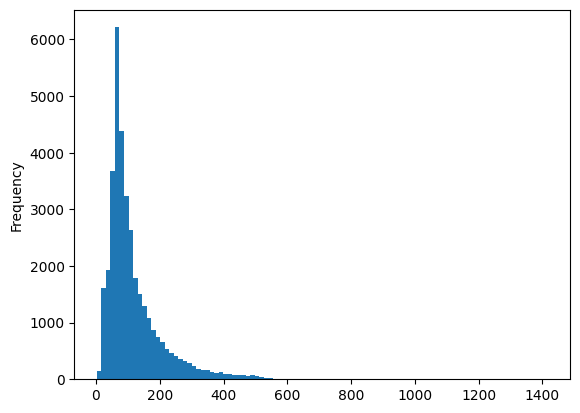

In [11]:
train_df['text_len'].plot.hist(bins=100)

In [12]:
# train_df.to_csv('train.csv', index=False)
# valid_df.to_csv('valid.csv', index=False)
# test_df.to_csv('test.csv', index=False)

# Dataset

In [4]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, data, max_len):
        # self.text = np.vstack(data['padded_text'].values).astype(int)
        # self.label = data['label'].values
        # self.text_l = data['text_len'].values
        self.data = data
        self.max_seq_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # t, lbl, t1, t2, len_t = self.data.iloc[idx]
        # t = [i for i in self.text[idx]]
        # return torch.tensor[i for i in self.text[idx]]), torch.tensor(self.label[idx]), torch.tensor(self.text_l[idx])
        text, label, tokenized_text, len_t = self.data.iloc[idx]

        tokenized_text = [int(i) for i in tokenized_text.split()]
        text_t = torch.zeros(self.max_seq_len).long()
        if self.max_seq_len < len_t:
            text_t = torch.LongTensor(tokenized_text[:self.max_seq_len])
        else:
            text_t[:len_t] = torch.LongTensor(tokenized_text)
        # t1 = self.pad_seq(t1)

        return text_t, torch.tensor(label).float(), len_t



# def batch_collate(batch):
#     # batch.sort(key=lambda x: len(x[0]), reverse=True)
#     text_list = [b[0] for b in batch]
#     print(batch[0][0])
#     text_list = nn.utils.rnn.pad_sequence(text_list, batch_first=True, padding_value=vocab['<PAD>'])
#     label_list = torch.tensor([b[1] for b in batch])
#     lens = torch.tensor([b[2] for b in batch])

#     return text_list, label_list, lens


# train_x = np.vstack(train_df['padded_text'].values)
# train_y = train_df['label'].values

# valid_x = np.vstack(valid_df['padded_text'].values)
# valid_y = valid_df['label'].values

# test_x = np.vstack(test_df['padded_text'].values)
# test_y = test_df['label'].values

# train_len_x = train_df['text_len'].values
# valid_len_x = valid_df['text_len'].values
# test_len_x = test_df['text_len'].values

# trainset = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))  #, torch.from_numpy(train_len_x))
# validset = TensorDataset(torch.from_numpy(valid_x), torch.from_numpy(valid_y))  #, torch.from_numpy(valid_len_x))
# testset = TensorDataset(torch.from_numpy(test_x), torch.from_numpy(test_y))     #, torch.from_numpy(test_len_x))

trainset = TextDataset(train_df, max_len)
validset = TextDataset(valid_df, max_len)
testset = TextDataset(test_df, max_len)

BATCH_SIZE = 64 # batch size for training
train_dataloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)    #, collate_fn=batch_collate)
valid_dataloader = DataLoader(validset, batch_size=BATCH_SIZE, shuffle=True)    #, collate_fn=batch_collate)
test_dataloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True)      #, collate_fn=batch_collate)


## Batch Example

In [5]:
for idx, (text, label, lens) in enumerate(train_dataloader):
    if idx < 1:
        print(len(train_dataloader))
        print(label.size(), label.dtype)
        print(text.size(), text.dtype)
        print(len(lens))
    else:
        break

563
torch.Size([64]) torch.float32
torch.Size([64, 200]) torch.int64
64


# Glove embedding

In [7]:
def build_weight_matrix(target_vocab, tokenizer):
    glove = torchtext.vocab.GloVe('6B', dim=300, cache='/workspace/books/.vector_cache')
    # print(len(glove), glove.dim)

    weight_matrix = np.zeros((len(target_vocab), glove.dim))
    for i, word in enumerate(target_vocab.items()):
        try:
            weight_matrix[i] = glove.get_vecs_by_tokens(target_vocab[word], lower_case_backup=True)
        except:
            weight_matrix[i] = np.random.normal(scale=0.6, size=(glove.dim, ))
    # print(weight_matrix.shape)
    return weight_matrix

weights_matrix = build_weight_matrix(vocab, tokenizer)
print('Weight matrix shape: ', weights_matrix.shape)

Weight matrix shape:  (50000, 300)


# Network

## Model-1

using sigmoid at the end with static padding

In [8]:
class BiLSTM(nn.Module):
    
    def __init__(self, max_features, embed_size, embedding_matrix):
        super(BiLSTM, self).__init__()
        self.hidden_size = 64
        drp = 0.1
        n_classes = 1
        self.embedding = nn.Embedding(max_features, embed_size)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(embed_size, self.hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(self.hidden_size*4 , 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(drp)
        self.out = nn.Linear(64, n_classes)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h_embedding = self.embedding(x)
        h_lstm, _ = self.lstm(h_embedding)
        avg_pool = torch.mean(h_lstm, 1)
        max_pool, _ = torch.max(h_lstm, 1)
        conc = torch.cat(( avg_pool, max_pool), 1)
        conc = self.relu(self.linear(conc))
        conc = self.dropout(conc)
        out = self.act(self.out(conc))
        return out

### init

In [9]:
size_of_vocab = len(vocab)
embedding_dim = 300

# instantiate the model
model = BiLSTM(max_features=size_of_vocab, embed_size=embedding_dim, embedding_matrix=weights_matrix).to(device)

print(model)

BiLSTM(
  (embedding): Embedding(50000, 300)
  (lstm): LSTM(300, 64, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=64, out_features=1, bias=True)
  (act): Sigmoid()
)


### Model Summary

In [12]:
torchinfo.summary(model, input=torch.rand((64, 200)))

Layer (type:depth-idx)                   Param #
BiLSTM                                   --
├─Embedding: 1-1                         (15,000,000)
├─LSTM: 1-2                              187,392
├─Linear: 1-3                            16,448
├─ReLU: 1-4                              --
├─Dropout: 1-5                           --
├─Linear: 1-6                            65
├─Sigmoid: 1-7                           --
Total params: 15,203,905
Trainable params: 203,905
Non-trainable params: 15,000,000

### Hyper Parameters, optimizer & criterion

In [13]:
# Hyperparameters
EPOCHS = 100 # epoch
LR = 0.001  # learning rate

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCELoss()   # nn.BCEWithLogitsLoss()

### Epoch Execution

In [23]:
def run_epoch(net, loader, optim, criterion, training):
    if training:
        net.train()
    else:
        net.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_count = 0
    for idx, (text, label, lens) in enumerate(loader):
        text, label, t_length = text.to(device), label.to(device), lens
        
        with torch.set_grad_enabled(training):
            out = net(text)
            loss = criterion(out, label.view_as(out))
            predictions = out.squeeze(1)

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 5.)
            optim.step()
            optim.zero_grad()

        # Compute the loss & accuracy
        predictions = predictions.detach().float().cpu().numpy()
        label = label.detach().cpu().numpy()
        total_acc += (np.round(predictions) == label).sum().item()
        total_count += text.size(0)
        total_loss += loss.item()
    
    return total_loss/total_count, total_acc/total_count


## Model-2

with dynamic padding and sigmoid

In [41]:
class Classifier(nn.Module):
    #define all the layers used in model
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, 
                 bidirectional, dropout, embedding_matrix):
        #Constructor
        super().__init__()          
        
        #embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = False
                
        #lstm layer
        self.lstm = nn.LSTM(embedding_dim, 
                           hidden_dim, 
                           num_layers=n_layers, 
                           bidirectional=bidirectional, 
                           dropout=dropout,
                           batch_first=True)
        
        #dense layer
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
        #activation function
        self.act = nn.Sigmoid()
        
    def forward(self, text, text_lengths):
        
        #text = [batch size,sent_length]
        embedded = self.embedding(text)
        #embedded = [batch size, sent_len, emb dim]
        # print(embedded.shape)
      
        #packed sequence
        # packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, text_lengths, batch_first=True, enforce_sorted=False)

        packed_output, (hidden, cell) = self.lstm(embedded)
        #hidden = [batch size, num layers * num directions,hid dim]
        #cell = [batch size, num layers * num directions,hid dim]
        
        # # either use pad_packed_sequence or torch.cat
        # output_unpacked, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        # hidden = output_unpacked[:, -1, :]

        #concat the final forward and backward hidden state
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim = 1)
                
        #hidden = [batch size, hid dim * num directions]
        dense_outputs=self.fc(hidden)

        #Final activation function
        outputs=self.act(dense_outputs)
        
        return outputs        

### init

In [42]:
size_of_vocab = len(vocab)
embedding_dim = 300
num_hidden_nodes = 16
num_output_nodes = 1
num_layers = 2
bidirection = 2
dropout = 0.2

# instantiate the model vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout
model = Classifier(vocab_size=size_of_vocab, embedding_dim=embedding_dim, hidden_dim=num_hidden_nodes, output_dim=num_output_nodes, n_layers=num_layers, 
                    bidirectional=(bidirection == 2), dropout=dropout, embedding_matrix=weights_matrix).to(device)

### Model Summary

In [43]:
torchinfo.summary(model, input=torch.rand((64, 200)))

Layer (type:depth-idx)                   Param #
Classifier                               --
├─Embedding: 1-1                         (15,000,000)
├─LSTM: 1-2                              47,104
├─Linear: 1-3                            33
├─Sigmoid: 1-4                           --
Total params: 15,047,137
Trainable params: 47,137
Non-trainable params: 15,000,000

### Hyper Parameters, Optimizer & Criterion

In [44]:
# Hyperparameters
EPOCHS = 100 # epoch
LR = 0.0001  # learning rate

optimizer = torch.optim.Adam(model.parameters())
criterion = nn.BCELoss()

### Epoch Execution

In [45]:
def run_epoch(net, loader, optim, criterion, training):
    if training:
        net.train()
    else:
        net.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_count = 0
    for idx, (text, label, lens) in enumerate(loader):
        text, label, t_length = text.to(device), label.to(device), lens
        
        with torch.set_grad_enabled(training):
            prediction = net(text, t_length)
            # _, predictions = torch.max(predicted_label.data, 1)
            loss = criterion(prediction.squeeze(), label.float())

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 5.)
            optim.step()
            optim.zero_grad()

        # Compute the loss & accuracy
        # total_acc += (predicted_label.argmax(1) == label).sum().item()
        pred_label = torch.tensor([1 if i > 0.5 else 0 for i in prediction])
        total_acc += (pred_label.cpu().numpy() == label.detach().cpu().numpy()).sum().item()
        total_count += label.size(0)
        total_loss += loss.item()
    
    return total_loss/total_count, total_acc/total_count


## Model-3

with Softmax

In [88]:
class BiLSTM(nn.Module):
    
    def __init__(self, max_features, num_class, embed_size, embedding_matrix):
        super(BiLSTM, self).__init__()
        self.hidden_size = 64
        drp = 0.1
        n_classes = num_class
        self.embedding = nn.Embedding(max_features, embed_size)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(embed_size, self.hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(self.hidden_size*4 , 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(drp)
        self.out = nn.Linear(64, n_classes)
        # self.act = nn.Sigmoid()

    def forward(self, x):
        h_embedding = self.embedding(x)
        h_lstm, _ = self.lstm(h_embedding)
        avg_pool = torch.mean(h_lstm, 1)
        max_pool, _ = torch.max(h_lstm, 1)
        conc = torch.cat(( avg_pool, max_pool), 1)
        conc = self.relu(self.linear(conc))
        conc = self.dropout(conc)
        out = log_softmax(self.out(conc), dim=-1)
        return out

### init

In [89]:
size_of_vocab = len(vocab)
embedding_dim = 300

# instantiate the model
model = BiLSTM(max_features=size_of_vocab, num_class=2, embed_size=embedding_dim, embedding_matrix=weights_matrix).to(device)

print(model)

BiLSTM(
  (embedding): Embedding(50000, 300)
  (lstm): LSTM(300, 64, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
  (out): Linear(in_features=64, out_features=2, bias=True)
)


### Model Summary

In [90]:
torchinfo.summary(model, input=torch.rand((64, 200)))

Layer (type:depth-idx)                   Param #
BiLSTM                                   --
├─Embedding: 1-1                         (15,000,000)
├─LSTM: 1-2                              187,392
├─Linear: 1-3                            16,448
├─ReLU: 1-4                              --
├─Dropout: 1-5                           --
├─Linear: 1-6                            130
Total params: 15,203,970
Trainable params: 203,970
Non-trainable params: 15,000,000

### Hyper Parameters, Optimizer & Criterion

In [91]:
# Hyperparameters
EPOCHS = 100 # epoch
LR = 0.001  # learning rate

optimizer = torch.optim.Adam(model.parameters())
# criterion = nn.BCELoss()   # nn.BCEWithLogitsLoss()
criterion = nn.CrossEntropyLoss()

### Epoch Execution

In [94]:
def run_epoch(net, loader, optim, criterion, training):
    if training:
        net.train()
    else:
        net.eval()

    total_loss = 0.0
    total_acc = 0.0
    total_count = 0
    for idx, (text, label, lens) in enumerate(loader):
        text, label, t_length = text.to(device), label.to(device), lens
        
        with torch.set_grad_enabled(training):
            out = net(text)
            _, predictions = torch.max(out.data, 1)
            loss = criterion(out, label.long())

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 5.)
            optim.step()
            optim.zero_grad()

        # Compute the loss & accuracy
        predictions = predictions.detach().cpu().numpy()
        label = label.detach().cpu().numpy()
        total_acc += (np.round(predictions) == label).sum().item()
        
        total_count += text.size(0)
        total_loss += loss.item()
    
    return total_loss/total_count, total_acc/total_count


# Training

In [96]:
start_time = time.time()
best_val_loss = float('Inf')
early_stop_counter = 15

for e in range(EPOCHS):
    t1 = time.time()

    train_loss, train_acc = run_epoch(model, train_dataloader, optimizer, criterion, training=True)
    val_loss, val_acc = run_epoch(model, valid_dataloader, optimizer, criterion, training=False)

    print("Epoch:{0:3d} | train_loss:{1:.6f} | train_acc:{2:.6f} | "
          "val_loss:{3:.6f} | val_acc:{4:.6f} | time:{5} | Saving: {6} ".format(e, train_loss, train_acc, val_loss, val_acc, 
                                                                                str(timedelta(seconds=time.time() - t1)), 
                                                                                'True' if val_loss < best_val_loss else 'False'))

    if val_loss < best_val_loss:
        # print("Saving network, previous best test loss {:.6f}, current test loss {:.6f}".format(best_val_loss, val_loss))
        # best_model_wts = copy.deepcopy(net.state_dict())
        torch.save(model.state_dict(), os.path.join(os.getcwd(), 
                                                    # checkpoint_dir, 
                                                    'model-3.pth'))
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        # print('test loss has not improved from {:.3f} since last {} epoch(s)'.format(best_val_loss, counter))
        if counter >= early_stop_counter:
            print('test loss has not improved from {:.3f} since last {} epoch(s)'.format(best_val_loss, counter))
            stopped_at_epoch = e
            print('- - ' * 20)
            print('Early Stopping Now!!!!'.center(80))
            print('- - ' * 20)
            break

Epoch:  0 | train_loss:0.004036 | train_acc:0.895167 | val_loss:0.005316 | val_acc:0.854000 | time:0:00:34.874288 | Saving: True 
Epoch:  1 | train_loss:0.002495 | train_acc:0.943333 | val_loss:0.005563 | val_acc:0.868250 | time:0:00:34.177012 | Saving: False 
Epoch:  2 | train_loss:0.001209 | train_acc:0.976917 | val_loss:0.006461 | val_acc:0.862000 | time:0:00:34.455941 | Saving: False 
Epoch:  3 | train_loss:0.000480 | train_acc:0.992722 | val_loss:0.008243 | val_acc:0.858000 | time:0:00:34.227045 | Saving: False 
Epoch:  4 | train_loss:0.000228 | train_acc:0.996306 | val_loss:0.009309 | val_acc:0.860000 | time:0:00:34.400718 | Saving: False 
Epoch:  5 | train_loss:0.000218 | train_acc:0.996111 | val_loss:0.009686 | val_acc:0.858750 | time:0:00:35.536334 | Saving: False 
Epoch:  6 | train_loss:0.000564 | train_acc:0.986028 | val_loss:0.011338 | val_acc:0.841000 | time:0:00:35.307600 | Saving: False 
Epoch:  7 | train_loss:0.000379 | train_acc:0.991444 | val_loss:0.011228 | val_acc:0

# Testing

In [97]:
# model = BiLSTM(max_features=size_of_vocab, embed_size=embedding_dim, embedding_matrix=weights_matrix).to(device)
model.load_state_dict(torch.load("model-3.pth", map_location=device))

print('Checking the results of test dataset..')
_, accu_test = run_epoch(model, test_dataloader, optimizer, criterion, training=False)
print('test accuracy {:8.3f}'.format(accu_test))

Checking the results of test dataset..
test accuracy    0.863
